<a href="https://colab.research.google.com/github/karthikkumarp2416sse-bit/machine-learning/blob/main/ex_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# Suppress warnings from Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)

# Assuming df_agg is available from previous steps with 'date' and 'total_sale_dollars'
# For demonstration purposes, let's create a dummy df_agg if it doesn't exist
# In a real scenario, this would be your actual aggregated sales data.
try:
    # Try to use an existing df_agg
    _ = df_agg.head()
except NameError:
    # If df_agg is not defined, create a dummy one
    print("df_agg not found, creating dummy data for demonstration.")
    dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
    sales = np.random.randint(500, 2000, size=100) + np.sin(np.arange(100)/7 * 2 * np.pi) * 200 # Add some seasonality
    sales[sales < 0] = 0 # Ensure no negative sales
    df_agg = pd.DataFrame({'date': dates, 'total_sale_dollars': sales})

print("Original df_agg head:")
display(df_agg.head())

df_agg not found, creating dummy data for demonstration.
Original df_agg head:


,date,total_sale_dollars
0,2023-01-01,1431.000000
1,2023-01-02,1863.366296
2,2023-01-03,1930.985582
3,2023-01-04,912.776748
4,2023-01-05,1026.223252


In [2]:
# Prepare data for Prophet: rename columns to 'ds' (datestamp) and 'y' (target variable)
# Prophet expects the date column to be named 'ds' and the value column to be named 'y'.
prophet_df = df_agg[['date', 'total_sale_dollars']].copy()
prophet_df.rename(columns={'date': 'ds', 'total_sale_dollars': 'y'}, inplace=True)

# Ensure 'ds' is datetime type
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

print("Prophet data head:")
display(prophet_df.head())

Prophet data head:


,ds,y
0,2023-01-01,1431.000000
1,2023-01-02,1863.366296
2,2023-01-03,1930.985582
3,2023-01-04,912.776748
4,2023-01-05,1026.223252


In [3]:
# Initialize and fit the Prophet model
# You can add parameters like seasonality_mode, yearly_seasonality, weekly_seasonality if known
model = Prophet(
    interval_width=0.95, # Confidence interval
    seasonality_mode='multiplicative', # 'additive' or 'multiplicative'
    yearly_seasonality=False, # Set to True if you have at least 2 years of data
    weekly_seasonality=True, # Set to True if you have weekly patterns
    daily_seasonality=False # Set to True if you have daily patterns
)

# Add custom seasonality if desired (e.g., monthly)
# model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

model.fit(prophet_df)
print("Prophet model fitted.")

Prophet model fitted.


In [4]:
# Create a DataFrame with future dates for forecasting
# Let's forecast for the next 30 days
future = model.make_future_dataframe(periods=30, freq='D')

print("Future dataframe head:")
display(future.tail())

Future dataframe head:


,ds
125,2023-05-06
126,2023-05-07
127,2023-05-08
128,2023-05-09
129,2023-05-10


In [5]:
# Make predictions
forecast = model.predict(future)

print("Forecast dataframe head:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Forecast dataframe head:


,ds,yhat,yhat_lower,yhat_upper
125,2023-05-06,869.295899,51.494076,1616.068822
126,2023-05-07,1228.364073,457.542387,2131.476797
127,2023-05-08,1381.854787,569.442218,2252.344900
128,2023-05-09,1396.574939,609.334648,2218.726457
129,2023-05-10,1249.203532,483.213639,2036.152438


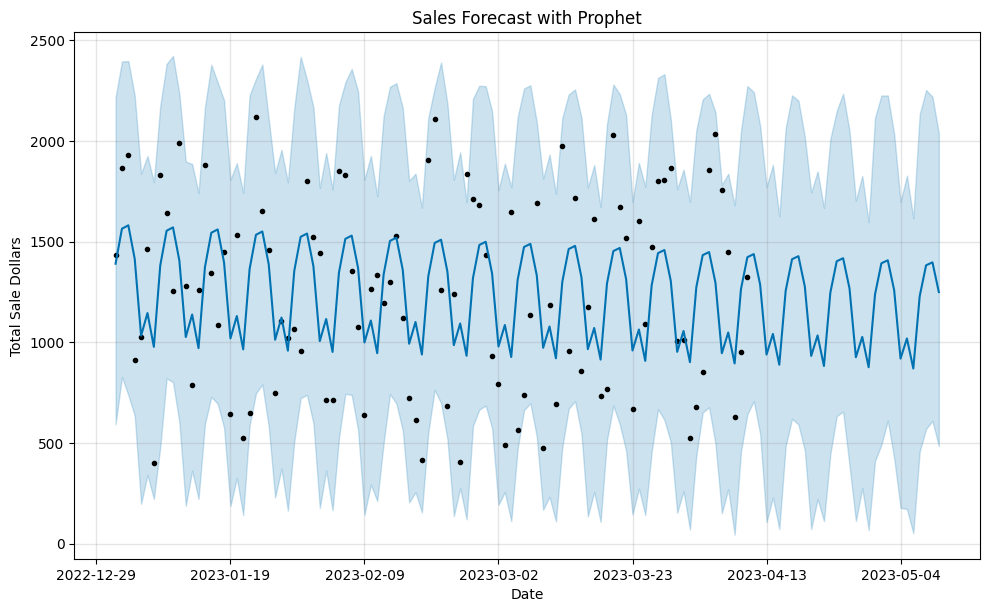

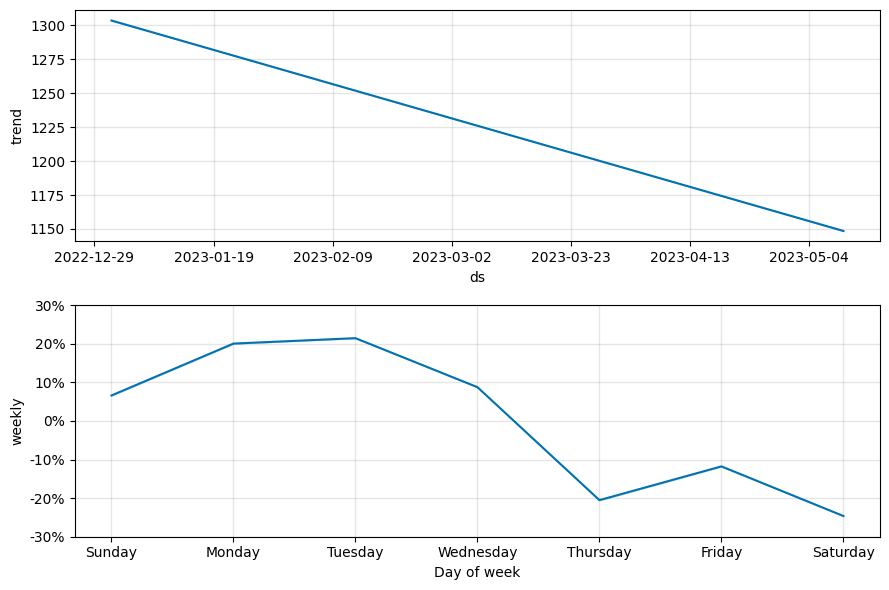

In [6]:
# Plot the forecast
fig = model.plot(forecast)
plt.title('Sales Forecast with Prophet')
plt.xlabel('Date')
plt.ylabel('Total Sale Dollars')
plt.show()

# Plot the components of the forecast (trend, seasonality)
fig2 = model.plot_components(forecast)
plt.show()